# Benchmarking Spatial Proteomics Normalization

Metrics for evaluating normalization quality across three axes:

1. **Signal-to-Noise Ratio (SNR)** — Does normalization improve separation of
   biological signal (cell-type differences) from technical noise?
2. **Tile / FOV Effects** — Does normalization reduce systematic center-vs-border
   intensity bias and tile-to-tile variability?
3. **Spatial Autocorrelation** — Does normalization preserve meaningful spatial
   structure while removing artifactual spatial patterns?

Built on `scanpy`, `squidpy`, and `spatialdata`.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import spatialdata
from scipy import sparse, stats
from anndata import AnnData
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

/home/icb/daniel.strobl/miniconda3/envs/spatial-env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Load test dataset: CODEX mouse spleen

Goltsev et al. (2018) — 707k cells × 29 protein markers across 9 mouse spleens,
acquired with tile-based CODEX imaging. The `obs` DataFrame contains `cell_type`
and `tile` columns, which is exactly what the metrics below need.

In [2]:
import cellcharter as cc

adata_full = cc.datasets.codex_mouse_spleen()

# The dataset stores unscaled intensities in .raw — recover them
if adata_full.raw is not None:
    adata = adata_full.raw.to_adata()
    adata.obs = adata_full.obs.copy()
    adata.obsm = adata_full.obsm.copy()
    print("Recovered raw intensities from adata.raw")
else:
    adata = adata_full.copy()
    print("No .raw found — using .X directly")

print(adata)
print(f"\nobs columns: {list(adata.obs.columns)}")
print(f"obsm keys:   {list(adata.obsm.keys())}")
print(f"\nExpression range: [{adata.X.min():.2f}, {adata.X.max():.2f}]")
print(f"Cell types:  {adata.obs['cell_type'].nunique()} unique")
print(f"Tiles:       {adata.obs['tile'].nunique()} unique")

No .raw found — using .X directly
AnnData object with n_obs × n_vars = 707474 × 29
    obs: 'cell_type', 'i-niche', 'tile', 'area', 'dataset', 'stage', 'sample'
    uns: 'spatial', 'spatial_cluster_colors'
    obsm: 'blanks', 'spatial'

obs columns: ['cell_type', 'i-niche', 'tile', 'area', 'dataset', 'stage', 'sample']
obsm keys:   ['blanks', 'spatial']

Expression range: [-165324.44, 86349.25]
Cell types:  27 unique
Tiles:       252 unique


## Define normalization methods

Standard approaches for spatial proteomics intensity data:

| Method | Description |
|---|---|
| **raw** | Baseline — no transformation |
| **arcsinh1** | `arcsinh(x / 1)` — no dampening, stronger compression of extremes |
| **arcsinh5** | `arcsinh(x / 5)` — standard for mass-cytometry / CODEX |
| **zscore** | Per-marker z-scoring across all cells |
| **zscore_per_tile** | Per-marker z-score *within each tile* — explicitly removes tile mean shifts |
| **quantile** | Per-marker quantile normalization to a uniform [0, 1] distribution |
| **clr** | Centered log-ratio — accounts for compositional nature of protein panels |

In [3]:
def _to_dense(X):
    if sparse.issparse(X):
        return np.asarray(X.todense(), dtype=np.float64)
    return np.asarray(X, dtype=np.float64)


def norm_arcsinh(adata: AnnData, cofactor: float = 5.0) -> AnnData:
    ad = adata.copy()
    ad.X = np.arcsinh(_to_dense(ad.X) / cofactor)
    return ad


def norm_zscore(adata: AnnData) -> AnnData:
    ad = adata.copy()
    ad.X = _to_dense(ad.X)
    sc.pp.scale(ad)
    return ad


def norm_zscore_per_tile(adata: AnnData, tile_col: str = "tile") -> AnnData:
    """Z-score each marker within each tile independently."""
    ad = adata.copy()
    X = _to_dense(ad.X)
    tiles = ad.obs[tile_col].values
    for tile_id in pd.unique(tiles):
        mask = tiles == tile_id
        Xt = X[mask]
        mu = Xt.mean(axis=0)
        std = Xt.std(axis=0)
        std[std == 0] = 1.0
        X[mask] = (Xt - mu) / std
    ad.X = X
    return ad


def norm_quantile(adata: AnnData) -> AnnData:
    """Per-marker quantile normalization to uniform [0, 1]."""
    ad = adata.copy()
    X = _to_dense(ad.X)
    for j in range(X.shape[1]):
        col = X[:, j]
        ranked = stats.rankdata(col, method="average")
        X[:, j] = ranked / (len(ranked) + 1)
    ad.X = X
    return ad


def norm_clr(adata: AnnData) -> AnnData:
    """Centered log-ratio transform (per cell)."""
    ad = adata.copy()
    X = _to_dense(ad.X)
    X = np.clip(X, 1e-10, None)  # avoid log(0)
    log_X = np.log(X)
    geo_mean = log_X.mean(axis=1, keepdims=True)
    ad.X = log_X - geo_mean
    return ad


# Build dict of normalized AnnDatas
adatas = {
    "raw": adata.copy(),
    "arcsinh1": norm_arcsinh(adata, cofactor=1),
    "arcsinh5": norm_arcsinh(adata, cofactor=5),
    "zscore": norm_zscore(adata),
    "zscore_per_tile": norm_zscore_per_tile(adata, tile_col="tile"),
    "quantile": norm_quantile(adata),
    "clr": norm_clr(adata),
}

for name, ad in adatas.items():
    X = _to_dense(ad.X)
    print(f"  {name:20s}  shape={ad.shape}  range=[{X.min():.3f}, {X.max():.3f}]")

  raw                   shape=(707474, 29)  range=[-165324.438, 86349.250]
  arcsinh1              shape=(707474, 29)  range=[-12.709, 12.059]
  arcsinh5              shape=(707474, 29)  range=[-11.099, 10.450]
  zscore                shape=(707474, 29)  range=[-103.770, 64.958]
  zscore_per_tile       shape=(707474, 29)  range=[-48.126, 51.859]
  quantile              shape=(707474, 29)  range=[0.000, 1.000]
  clr                   shape=(707474, 29)  range=[-31.247, 29.931]


## 1. Signal-to-Noise Ratio

Per-marker **F-statistic** (between-group / within-group variance using cell-type labels)
quantifies how well a normalization separates biological signal from noise.
Complemented by the **within-type CV** (lower = less noise) and a global
**silhouette score** in PCA space.

In [4]:
def compute_snr_metrics(
    adata: AnnData,
    cell_type_col: str,
    markers: Optional[list[str]] = None,
) -> pd.DataFrame:
    """Per-marker signal-to-noise ratio metrics based on cell-type grouping.

    For each marker computes:
    - f_statistic: one-way ANOVA F (between / within group variance).
      Higher → better cell-type separation.
    - mean_within_cv: average coefficient of variation within cell types.
      Lower → less intra-type noise.
    - dynamic_range: 1st–99th percentile range.

    Parameters
    ----------
    adata
        Annotated data matrix with expression in ``.X``.
    cell_type_col
        Column in ``.obs`` with cell-type labels.
    markers
        Subset of ``var_names`` to evaluate. ``None`` = all.

    Returns
    -------
    DataFrame indexed by marker with metric columns.
    """
    if markers is None:
        markers = adata.var_names.tolist()

    X = adata[:, markers].X
    if sparse.issparse(X):
        X = np.asarray(X.todense())
    X = np.asarray(X, dtype=np.float64)

    labels = adata.obs[cell_type_col].values
    unique_labels = pd.unique(labels)

    records = []
    for i, marker in enumerate(markers):
        x = X[:, i]
        grand_mean = x.mean()

        group_n, group_mean, group_var, cvs = [], [], [], []
        for lab in unique_labels:
            g = x[labels == lab]
            if g.shape[0] < 2:
                continue
            mu = g.mean()
            group_n.append(g.shape[0])
            group_mean.append(mu)
            group_var.append(g.var(ddof=0))
            if mu > 0:
                cvs.append(g.std(ddof=1) / mu)

        group_n = np.array(group_n)
        group_mean = np.array(group_mean)
        group_var = np.array(group_var)

        k, N = len(group_n), group_n.sum()
        ss_between = (group_n * (group_mean - grand_mean) ** 2).sum()
        ss_within = (group_n * group_var).sum()
        df_between = k - 1
        df_within = N - k

        ms_between = ss_between / df_between if df_between > 0 else np.nan
        ms_within = ss_within / df_within if df_within > 0 else np.nan
        f_stat = ms_between / ms_within if ms_within > 0 else np.nan

        records.append(
            {
                "marker": marker,
                "f_statistic": f_stat,
                "mean_within_cv": np.mean(cvs) if cvs else np.nan,
                "dynamic_range": np.percentile(x, 99) - np.percentile(x, 1),
                "between_var": ms_between,
                "within_var": ms_within,
            }
        )

    return pd.DataFrame(records).set_index("marker")


def compute_silhouette(
    adata: AnnData,
    cell_type_col: str,
    n_pcs: int = 20,
    subsample: Optional[int] = 5000,
    random_state: int = 0,
) -> float:
    """Global silhouette score in PCA space as an aggregate SNR measure.

    Parameters
    ----------
    adata
        Annotated data matrix.
    cell_type_col
        Column in ``.obs`` with cell-type labels.
    n_pcs
        Number of PCs.
    subsample
        Max cells to use (for speed). ``None`` = all.

    Returns
    -------
    Mean silhouette score (higher is better, range [-1, 1]).
    """
    from sklearn.metrics import silhouette_score

    tmp = adata.copy()
    if subsample and tmp.n_obs > subsample:
        sc.pp.subsample(tmp, n_obs=subsample, random_state=random_state)
    sc.pp.pca(tmp, n_comps=min(n_pcs, tmp.n_vars - 1, tmp.n_obs - 1))
    return silhouette_score(tmp.obsm["X_pca"], tmp.obs[cell_type_col].values)

## 2. Tile / FOV Effects

Spatial proteomics platforms acquire images in tiles that suffer from
vignetting and registration artifacts. We classify cells within each tile as
**center** vs **border** (outer quantile by Chebyshev distance from tile
centroid) and compare expression:

| Metric | Meaning |
|---|---|
| `center_border_ratio` | Median ratio of center-mean to border-mean across tiles. Ideal = 1. |
| `center_border_pval` | Wilcoxon signed-rank test for systematic shift. |
| `tile_cv` | CV of per-tile means — captures tile-to-tile batch effects. |

In [5]:
def _classify_center_border(
    coords: np.ndarray,
    border_quantile: float = 0.75,
) -> np.ndarray:
    """Label cells as 'center' or 'border' within a single tile.

    Uses Chebyshev distance from tile centroid; cells beyond
    ``border_quantile`` of distances are 'border'.
    """
    centroid = coords.mean(axis=0)
    dist = np.max(np.abs(coords - centroid), axis=1)
    threshold = np.quantile(dist, border_quantile)
    return np.where(dist <= threshold, "center", "border")


def compute_tile_effect_metrics(
    adata: AnnData,
    tile_col: str,
    spatial_key: str = "spatial",
    markers: Optional[list[str]] = None,
    border_quantile: float = 0.75,
    min_cells_per_tile: int = 30,
) -> dict[str, pd.DataFrame]:
    """Quantify tile / FOV artifacts.

    Returns a dict with two DataFrames:

    ``per_marker``
        Aggregated across tiles — center/border ratio, Wilcoxon p-value,
        tile-to-tile CV.
    ``per_tile``
        Per-tile summary with center/border means per marker.

    Parameters
    ----------
    adata
        Annotated data matrix.
    tile_col
        Column in ``.obs`` identifying tile / FOV.
    spatial_key
        Key in ``.obsm`` for spatial coordinates.
    markers
        Subset of ``var_names``. ``None`` = all.
    border_quantile
        Quantile threshold for border classification (0–1).
    min_cells_per_tile
        Tiles with fewer cells are excluded.
    """
    if markers is None:
        markers = adata.var_names.tolist()

    X = adata[:, markers].X
    if sparse.issparse(X):
        X = np.asarray(X.todense())
    X = np.asarray(X, dtype=np.float64)

    coords = np.array(adata.obsm[spatial_key])
    tiles = adata.obs[tile_col].values
    unique_tiles = pd.unique(tiles)

    zone = np.empty(adata.n_obs, dtype=object)
    for tile_id in unique_tiles:
        mask = tiles == tile_id
        if mask.sum() < min_cells_per_tile:
            zone[mask] = "excluded"
            continue
        zone[mask] = _classify_center_border(
            coords[mask], border_quantile=border_quantile
        )

    center_means = {m: [] for m in markers}
    border_means = {m: [] for m in markers}
    tile_records = []

    for tile_id in unique_tiles:
        tmask = tiles == tile_id
        if tmask.sum() < min_cells_per_tile:
            continue

        c_mask = tmask & (zone == "center")
        b_mask = tmask & (zone == "border")
        rec = {
            "tile": tile_id,
            "n_cells": int(tmask.sum()),
            "n_center": int(c_mask.sum()),
            "n_border": int(b_mask.sum()),
        }
        for j, m in enumerate(markers):
            c_mean = float(X[c_mask, j].mean()) if c_mask.any() else np.nan
            b_mean = float(X[b_mask, j].mean()) if b_mask.any() else np.nan
            rec[f"{m}_center_mean"] = c_mean
            rec[f"{m}_border_mean"] = b_mean
            center_means[m].append(c_mean)
            border_means[m].append(b_mean)
        tile_records.append(rec)

    per_tile = pd.DataFrame(tile_records)

    marker_records = []
    for m in markers:
        c = np.array(center_means[m])
        b = np.array(border_means[m])
        valid = np.isfinite(c) & np.isfinite(b) & (b > 0)
        ratios = c[valid] / b[valid]

        pval = np.nan
        if valid.sum() >= 5:
            _, pval = stats.wilcoxon(c[valid] - b[valid])

        all_tile_means = np.concatenate([c[np.isfinite(c)], b[np.isfinite(b)]])
        tile_cv = (
            all_tile_means.std() / all_tile_means.mean()
            if all_tile_means.mean() > 0
            else np.nan
        )

        marker_records.append(
            {
                "marker": m,
                "center_border_ratio": np.median(ratios) if len(ratios) > 0 else np.nan,
                "center_border_pval": pval,
                "tile_cv": tile_cv,
                "n_tiles_used": int(valid.sum()),
            }
        )

    per_marker = pd.DataFrame(marker_records).set_index("marker")
    return {"per_marker": per_marker, "per_tile": per_tile}

## 3. Spatial Autocorrelation

**Moran's I** measures whether nearby cells have more similar expression than
expected by chance (positive autocorrelation). We compute it in two flavours:

- **Raw** — on the normalized expression directly. Biologically meaningful
  markers should retain high I (spatial organisation of cell types).
- **Residual** — on expression *after subtracting cell-type means*. High
  residual I flags remaining spatial artifacts (gradients, tile effects) that
  the normalization did not remove.

In [6]:
def compute_spatial_autocorrelation(
    adata: AnnData,
    markers: Optional[list[str]] = None,
    spatial_key: str = "spatial",
    n_neighs: int = 6,
    mode: str = "moran",
    n_perms: int = 100,
    copy: bool = True,
) -> pd.DataFrame:
    """Spatial autocorrelation per marker via squidpy.

    Parameters
    ----------
    adata
        Annotated data matrix.
    markers
        Subset of ``var_names``. ``None`` = all.
    spatial_key
        Key in ``.obsm`` for spatial coordinates.
    n_neighs
        Number of spatial neighbours for the graph.
    mode
        ``'moran'`` for Moran's I or ``'geary'`` for Geary's C.
    n_perms
        Permutations for significance testing. ``0`` = skip.
    copy
        Copy the AnnData before modifying.

    Returns
    -------
    DataFrame with autocorrelation statistics per marker.
    """
    if copy:
        adata = adata.copy()

    sq.gr.spatial_neighbors(
        adata,
        coord_type="generic",
        n_neighs=n_neighs,
        spatial_key=spatial_key,
    )
    sq.gr.spatial_autocorr(
        adata,
        mode=mode,
        genes=markers,
        n_perms=n_perms if n_perms > 0 else None,
    )

    key = "moranI" if mode == "moran" else "gearyC"
    return adata.uns[key].copy()


def compute_residual_spatial_autocorrelation(
    adata: AnnData,
    cell_type_col: str,
    markers: Optional[list[str]] = None,
    spatial_key: str = "spatial",
    n_neighs: int = 6,
    n_perms: int = 100,
) -> pd.DataFrame:
    """Moran's I on residuals after subtracting cell-type means.

    High residual autocorrelation flags remaining spatial artifacts
    (tile effects, staining gradients) not explained by cell-type
    composition.

    Parameters
    ----------
    adata
        Annotated data matrix.
    cell_type_col
        Column in ``.obs`` with cell-type labels.
    markers
        Subset of ``var_names``. ``None`` = all.
    spatial_key
        Key in ``.obsm`` for coordinates.
    n_neighs, n_perms
        Passed to ``compute_spatial_autocorrelation``.

    Returns
    -------
    DataFrame of Moran's I on residual expression.
    """
    if markers is None:
        markers = adata.var_names.tolist()

    tmp = adata[:, markers].copy()
    X = tmp.X
    if sparse.issparse(X):
        X = np.asarray(X.todense())
    X = np.asarray(X, dtype=np.float64)

    labels = tmp.obs[cell_type_col].values
    for lab in pd.unique(labels):
        mask = labels == lab
        X[mask] -= X[mask].mean(axis=0)

    tmp.X = X

    return compute_spatial_autocorrelation(
        tmp,
        markers=markers,
        spatial_key=spatial_key,
        n_neighs=n_neighs,
        mode="moran",
        n_perms=n_perms,
        copy=False,
    )

## 4. Benchmarking Framework

`benchmark_normalizations` runs all metrics on a dict of
`{name: AnnData}` pairs and `summarize_benchmark` condenses the results into
a single comparison table.

In [ ]:
def benchmark_normalizations(
    adatas: dict[str, AnnData],
    cell_type_col: str,
    tile_col: Optional[str] = None,
    spatial_key: str = "spatial",
    markers: Optional[list[str]] = None,
    n_neighs: int = 6,
) -> dict[str, dict]:
    """Run all metrics on multiple normalizations for comparison.

    Parameters
    ----------
    adatas
        Dict mapping normalization name → AnnData with that
        normalization applied. All must share the same obs/var structure.
    cell_type_col
        Column in ``.obs`` with cell-type labels.
    tile_col
        Column in ``.obs`` with tile/FOV identifiers. ``None`` skips
        tile-effect metrics.
    spatial_key
        Key in ``.obsm`` for spatial coordinates.
    markers
        Subset of ``var_names``. ``None`` = all.
    n_neighs
        Number of spatial neighbours for autocorrelation.

    Returns
    -------
    ``Dict[name → Dict]`` with keys ``'snr'``, ``'silhouette'``,
    ``'tile_effects'``, ``'spatial_autocorr'``, ``'residual_autocorr'``.
    """
    results = {}

    for name, ad in adatas.items():
        print(f"  [{name}] computing metrics …")
        res: dict = {}

        res["snr"] = compute_snr_metrics(ad, cell_type_col, markers)
        res["silhouette"] = compute_silhouette(ad, cell_type_col)

        if tile_col and tile_col in ad.obs.columns:
            res["tile_effects"] = compute_tile_effect_metrics(
                ad, tile_col, spatial_key=spatial_key, markers=markers
            )

        res["spatial_autocorr"] = compute_spatial_autocorrelation(
            ad, markers=markers, spatial_key=spatial_key, n_neighs=n_neighs, copy=True
        )
        res["residual_autocorr"] = compute_residual_spatial_autocorrelation(
            ad, cell_type_col, markers=markers, spatial_key=spatial_key, n_neighs=n_neighs
        )

        results[name] = res

    return results


def summarize_benchmark(results: dict[str, dict]) -> pd.DataFrame:
    """Condense benchmark results into a single comparison table.

    One row per normalization method with aggregate statistics.
    Arrows indicate the direction of improvement (↑ = higher is better,
    ↓ = lower is better).
    """
    rows = []
    for name, res in results.items():
        snr = res["snr"]
        row = {
            "normalization": name,
            "median_f_statistic ↑": snr["f_statistic"].median(),
            "mean_within_cv ↓": snr["mean_within_cv"].mean(),
            "mean_dynamic_range": snr["dynamic_range"].mean(),
            "silhouette_score ↑": res["silhouette"],
        }

        if "tile_effects" in res:
            te = res["tile_effects"]["per_marker"]
            row["median_center_border_ratio (→1)"] = te["center_border_ratio"].median()
            row["median_|log₂(c/b)| ↓"] = np.abs(
                np.log2(te["center_border_ratio"])
            ).median()
            row["mean_tile_cv ↓"] = te["tile_cv"].mean()
            row["frac_signif_tile_effect ↓"] = (te["center_border_pval"] < 0.05).mean()

        sa = res["spatial_autocorr"]
        stat_col = "I" if "I" in sa.columns else "C"
        row["mean_morans_I ↑"] = sa[stat_col].mean()

        ra = res["residual_autocorr"]
        stat_col_r = "I" if "I" in ra.columns else "C"
        row["mean_residual_morans_I ↓"] = ra[stat_col_r].mean()

        rows.append(row)

    return pd.DataFrame(rows).set_index("normalization")

## 5. Visualization

In [ ]:
def plot_benchmark_comparison(
    results: dict[str, dict],
    markers: Optional[list[str]] = None,
    figsize_scale: float = 1.0,
) -> plt.Figure:
    """Multi-panel comparison of normalization methods.

    Panels:
      1. F-statistic (log₁₀) per marker
      2. Within-group CV per marker
      3. Silhouette scores (bar)
      4. Center/border ratio (if tile info available)
      5. Moran's I per marker
      6. Residual Moran's I per marker
    """
    names = list(results.keys())
    has_tile = any("tile_effects" in r for r in results.values())
    n_panels = 5 + int(has_tile)

    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(4.5 * n_panels * figsize_scale, 5 * figsize_scale),
        constrained_layout=True,
    )

    def _to_long(results, key, value_col, transform=None):
        rows = []
        for nm, res in results.items():
            df = res.get(key) if isinstance(res.get(key), pd.DataFrame) else None
            if df is None:
                continue
            sub = df if markers is None else df.loc[df.index.intersection(markers)]
            for m, row in sub.iterrows():
                val = row[value_col]
                if transform:
                    val = transform(val)
                rows.append({"method": nm, "marker": m, value_col: val})
        return pd.DataFrame(rows)

    # F-statistic
    df = _to_long(results, "snr", "f_statistic", lambda v: np.log10(v + 1))
    df = df.rename(columns={"f_statistic": "F-stat (log₁₀)"})
    sns.boxplot(data=df, x="method", y="F-stat (log₁₀)", ax=axes[0], palette="Set2")
    axes[0].set_title("SNR: F-statistic")
    axes[0].tick_params(axis="x", rotation=45)

    # Within-group CV
    df = _to_long(results, "snr", "mean_within_cv")
    sns.boxplot(data=df, x="method", y="mean_within_cv", ax=axes[1], palette="Set2")
    axes[1].set_title("Intra-type CV")
    axes[1].tick_params(axis="x", rotation=45)

    # Silhouette
    sil_vals = [results[nm]["silhouette"] for nm in names]
    axes[2].bar(names, sil_vals, color=sns.color_palette("Set2", len(names)))
    axes[2].set_ylabel("Silhouette score")
    axes[2].set_title("Cell-type Silhouette")
    axes[2].tick_params(axis="x", rotation=45)

    panel_idx = 3

    # Center/border ratio (optional)
    if has_tile:
        rows = []
        for nm, res in results.items():
            if "tile_effects" not in res:
                continue
            te = res["tile_effects"]["per_marker"]
            sub = te if markers is None else te.loc[te.index.intersection(markers)]
            for m, row in sub.iterrows():
                rows.append(
                    {
                        "method": nm,
                        "marker": m,
                        "log₂(c/b)": np.log2(row["center_border_ratio"]),
                    }
                )
        sns.boxplot(
            data=pd.DataFrame(rows), x="method", y="log₂(c/b)",
            ax=axes[panel_idx], palette="Set2",
        )
        axes[panel_idx].axhline(0, ls="--", color="gray", lw=0.8)
        axes[panel_idx].set_title("Tile: Center vs Border")
        axes[panel_idx].tick_params(axis="x", rotation=45)
        panel_idx += 1

    # Moran's I
    rows = []
    for nm, res in results.items():
        sa = res["spatial_autocorr"]
        stat_col = "I" if "I" in sa.columns else "C"
        sub = sa if markers is None else sa.loc[sa.index.intersection(markers)]
        for m, row in sub.iterrows():
            rows.append({"method": nm, "marker": m, "Moran's I": row[stat_col]})
    sns.boxplot(
        data=pd.DataFrame(rows), x="method", y="Moran's I",
        ax=axes[panel_idx], palette="Set2",
    )
    axes[panel_idx].set_title("Spatial Autocorrelation")
    axes[panel_idx].tick_params(axis="x", rotation=45)
    panel_idx += 1

    # Residual Moran's I
    rows = []
    for nm, res in results.items():
        ra = res["residual_autocorr"]
        stat_col = "I" if "I" in ra.columns else "C"
        sub = ra if markers is None else ra.loc[ra.index.intersection(markers)]
        for m, row in sub.iterrows():
            rows.append({"method": nm, "marker": m, "Residual I": row[stat_col]})
    sns.boxplot(
        data=pd.DataFrame(rows), x="method", y="Residual I",
        ax=axes[panel_idx], palette="Set2",
    )
    axes[panel_idx].set_title("Residual Spatial Autocorr.")
    axes[panel_idx].tick_params(axis="x", rotation=45)

    fig.suptitle("Normalization Benchmark Comparison", fontsize=14, fontweight="bold")
    return fig


def plot_tile_center_border(
    tile_results: dict[str, pd.DataFrame],
    markers: Optional[list[str]] = None,
    max_markers: int = 12,
) -> plt.Figure:
    """Scatter: center mean vs border mean per tile for each marker.

    Deviation from the diagonal indicates systematic tile bias.
    """
    per_tile = tile_results["per_tile"]
    all_markers = tile_results["per_marker"].index.tolist()
    if markers:
        all_markers = [m for m in all_markers if m in markers]
    all_markers = all_markers[:max_markers]

    ncols = min(4, len(all_markers))
    nrows = int(np.ceil(len(all_markers) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 4 * nrows),
        squeeze=False, constrained_layout=True,
    )

    for idx, m in enumerate(all_markers):
        ax = axes[idx // ncols, idx % ncols]
        c = per_tile[f"{m}_center_mean"].values
        b = per_tile[f"{m}_border_mean"].values
        lo = min(np.nanmin(c), np.nanmin(b))
        hi = max(np.nanmax(c), np.nanmax(b))
        ax.scatter(b, c, s=15, alpha=0.6)
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
        ax.set_xlabel("Border mean")
        ax.set_ylabel("Center mean")
        ax.set_title(m)
        ax.set_aspect("equal")

    for idx in range(len(all_markers), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.suptitle("Center vs Border Mean per Tile", fontweight="bold")
    return fig


def plot_spatial_expression(
    adata: AnnData,
    marker: str,
    spatial_key: str = "spatial",
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
    point_size: float = 0.5,
) -> plt.Axes:
    """Spatial scatter of a single marker's expression."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    coords = np.array(adata.obsm[spatial_key])
    x = adata[:, marker].X
    if sparse.issparse(x):
        x = np.asarray(x.todense()).ravel()
    else:
        x = np.asarray(x).ravel()

    sc_plot = ax.scatter(
        coords[:, 0], coords[:, 1], c=x, s=point_size,
        cmap="viridis", rasterized=True,
    )
    plt.colorbar(sc_plot, ax=ax, label=marker)
    ax.set_title(title or f"{marker} expression")
    ax.set_aspect("equal")
    return ax

## Run benchmark on CODEX mouse spleen

In [9]:
results = benchmark_normalizations(
    adatas,
    cell_type_col="cell_type",
    tile_col="tile",
    spatial_key="spatial",
)

  [raw] computing metrics …


  0%|          | 0/100 [00:00<?, ?/s]

  0%|          | 0/100 [00:00<?, ?/s]

  [arcsinh1] computing metrics …


  0%|          | 0/100 [00:00<?, ?/s]

...

  0%|          | 0/100 [00:00<?, ?/s]

  0%|          | 0/100 [00:00<?, ?/s]

  [clr] computing metrics …


  0%|          | 0/100 [00:00<?, ?/s]

  0%|          | 0/100 [00:00<?, ?/s]

In [10]:
summary = summarize_benchmark(results)
summary.style.format(precision=4)

/home/icb/daniel.strobl/miniconda3/envs/spatial-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/icb/daniel.strobl/miniconda3/envs/spatial-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/icb/daniel.strobl/miniconda3/envs/spatial-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,median_f_statistic ↑,mean_within_cv ↓,mean_dynamic_range,silhouette_score ↑,median_center_border_ratio (→1),median_|log₂(c/b)| ↓,mean_tile_cv ↓,frac_signif_tile_effect ↓,mean_morans_I ↑,mean_residual_morans_I ↓
normalization,,,,,,,,,,
raw,15243.4998,2.2775,7429.5355,-0.0505,0.9951,0.0520,0.4552,0.7586,0.0236,0.0149
arcsinh1,4067.9896,1.6321,16.7524,-0.1271,0.9824,0.0257,0.1841,0.6897,0.0030,-0.0002
arcsinh5,4732.6249,1.1642,13.5336,-0.1056,0.9828,0.0250,0.1908,0.6552,0.0038,0.0000
zscore,15243.4998,16.0947,5.0898,0.0030,0.9506,0.3385,14.1209,0.6552,0.0236,0.0149
zscore_per_tile,9298.8936,25.4649,5.1818,-0.0255,-0.3330,nan,15.1276,1.0000,0.0116,0.0189
quantile,10107.8296,0.5770,0.9800,-0.0357,0.9895,0.0329,0.1709,0.8621,0.0237,0.0161
clr,2407.1800,13.8461,39.8602,-0.1441,1.0796,0.1191,22.0481,0.6552,0.0023,-0.0004


/tmp/ipykernel_537260/2916121943.py:76: RuntimeWarning: invalid value encountered in log2
  "log₂(c/b)": np.log2(row["center_border_ratio"]),


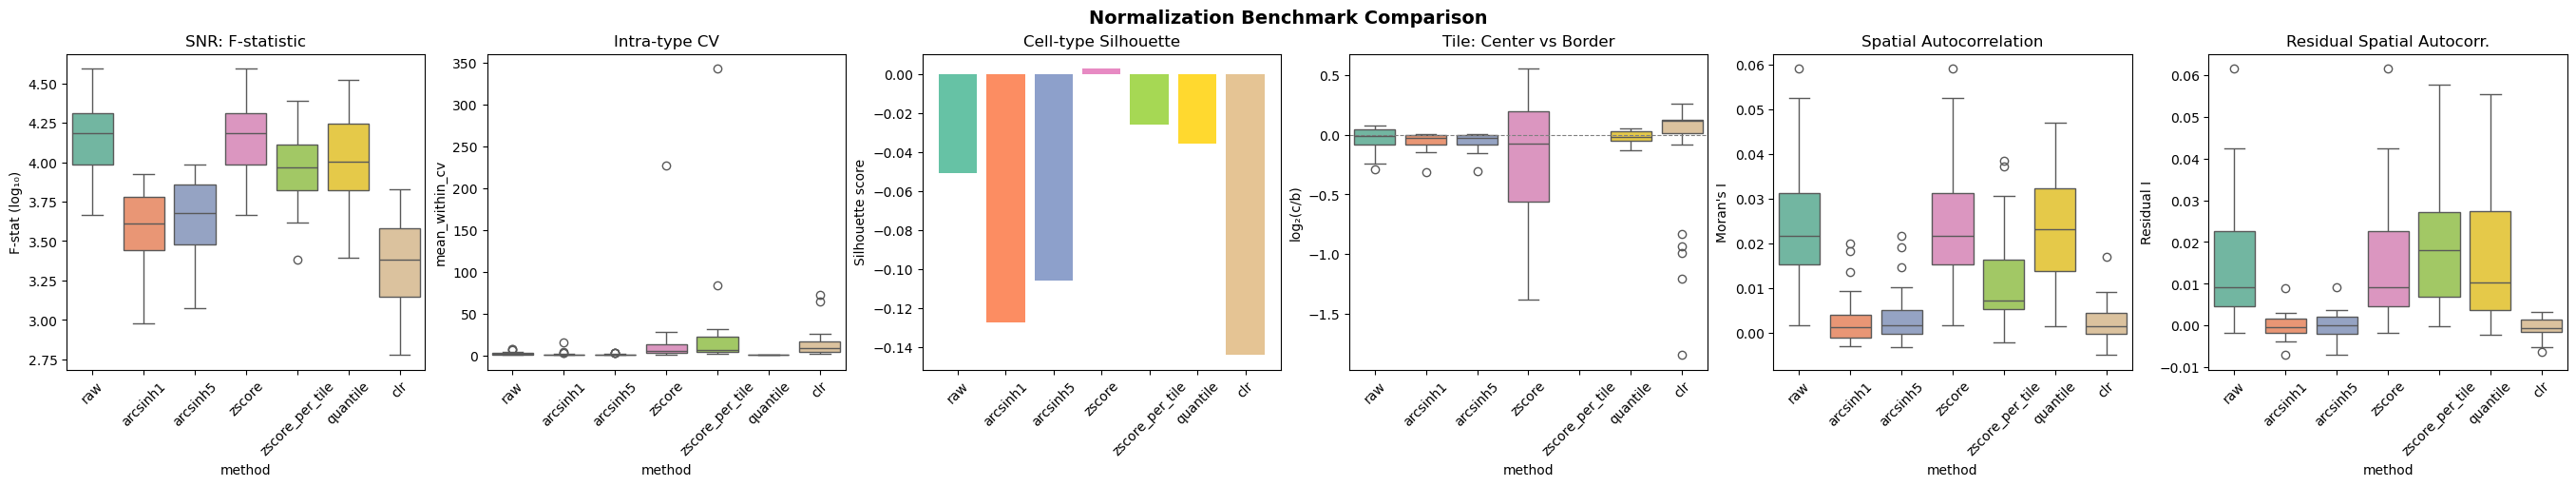

In [11]:
fig = plot_benchmark_comparison(results)
fig.savefig("benchmark_comparison.pdf", bbox_inches="tight")

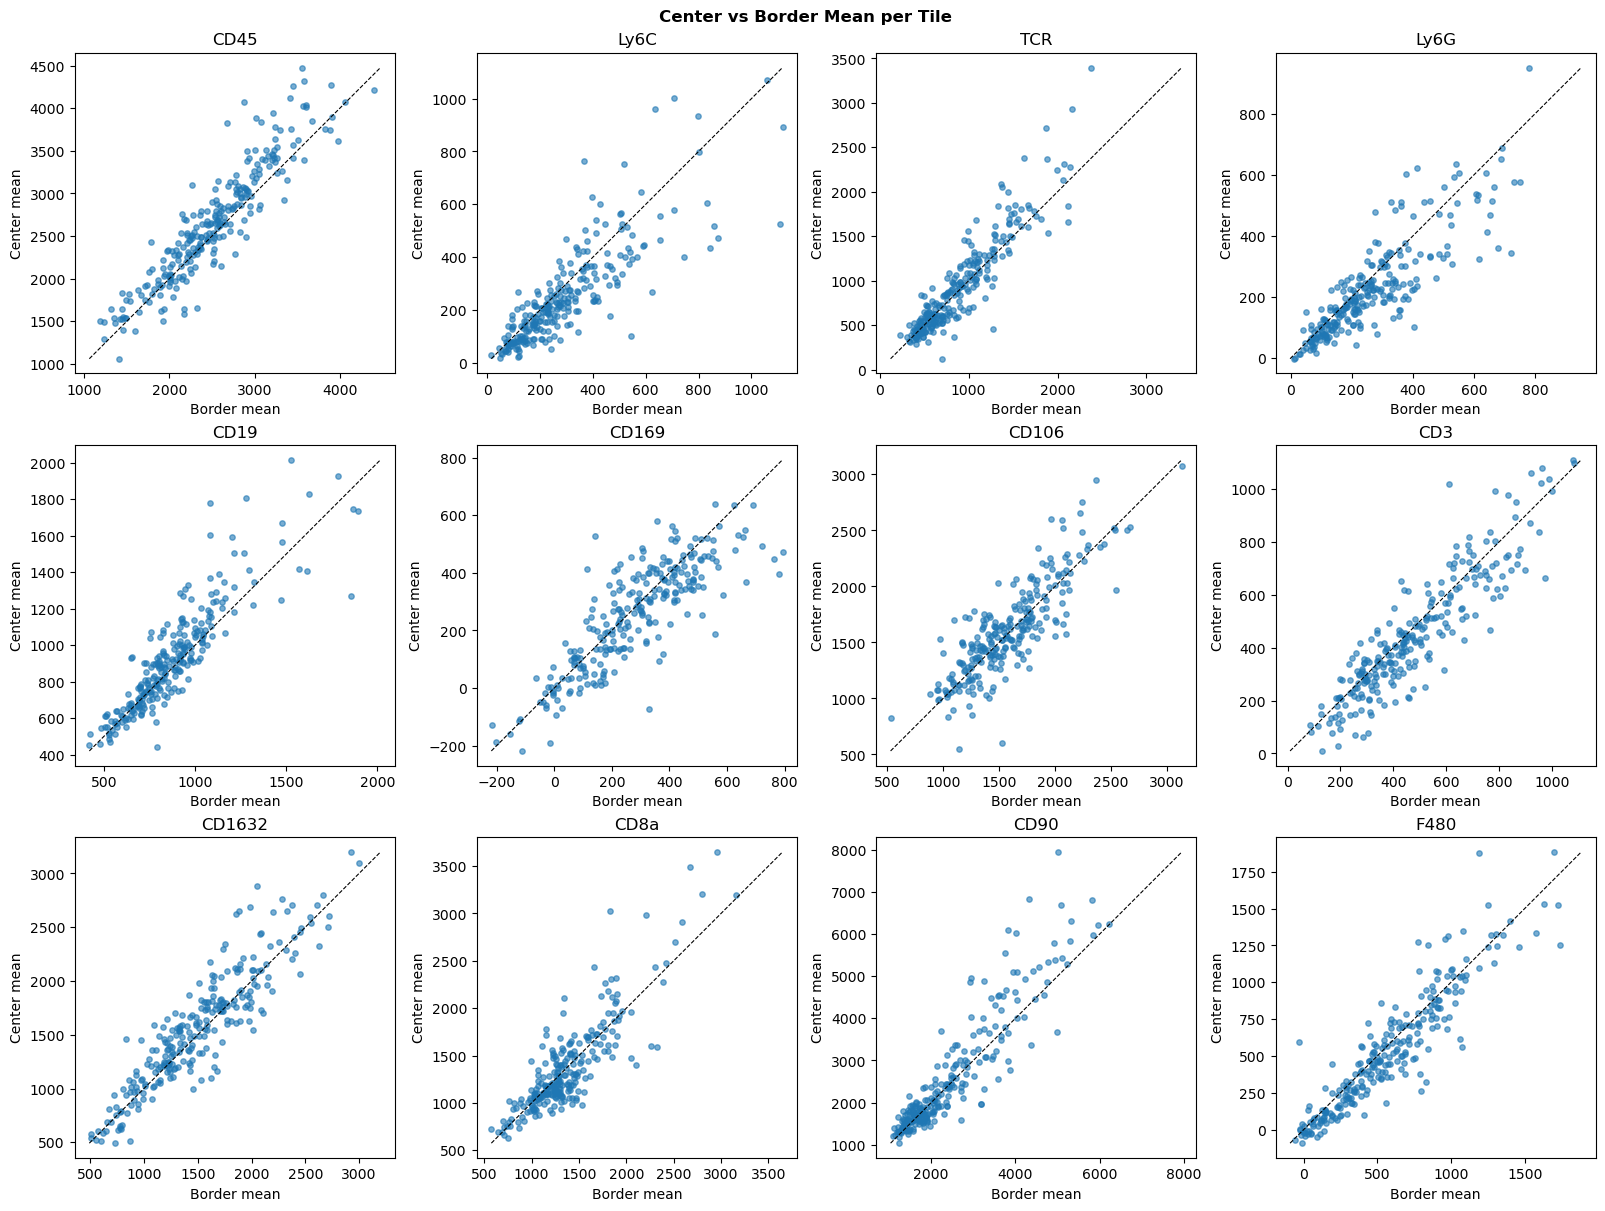

In [12]:
fig2 = plot_tile_center_border(results["raw"]["tile_effects"])
fig2.savefig("tile_center_border_raw.pdf", bbox_inches="tight")

In [18]:
def scale_benchmark(summary: pd.DataFrame) -> pd.DataFrame:
    """Rank-based scaling of each metric to [0, 1] where 1 = best.

    Each metric is ranked across methods (ties get average rank),
    then linearly mapped to [0, 1]. Robust to outliers unlike min–max.

    Columns with ↑ are "higher is better".
    Columns with ↓ or →1 are "lower is better" (inverted).
    """
    scaled = pd.DataFrame(index=summary.index)
    n = len(summary)

    drop_cols = [c for c in summary.columns if "↑" not in c and "↓" not in c and "→" not in c]
    summary = summary.drop(columns=drop_cols)

    for col in summary.columns:
        vals = summary[col].copy()

        if "→1" in col:
            vals = (vals - 1).abs()

        is_lower_better = "↓" in col or "→1" in col

        if is_lower_better:
            vals = -vals

        ranks = vals.rank(method="average", ascending=True, na_option="bottom")
        normed = (ranks - 1) / (n - 1) if n > 1 else pd.Series(1.0, index=vals.index)

        col_clean = col.replace(" ↑", "").replace(" ↓", "").replace(" (→1)", "")
        scaled[col_clean] = normed

    return scaled


scaled = scale_benchmark(summary)

styled = (
    scaled.style
    .format(precision=3)
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None)
)
styled

,median_f_statistic,mean_within_cv,silhouette_score,median_center_border_ratio,median_|log₂(c/b)|,mean_tile_cv,frac_signif_tile_effect,mean_morans_I,mean_residual_morans_I
normalization,,,,,,,,,
raw,0.917,0.500,0.500,1.000,0.333,0.500,0.333,0.667,0.500
arcsinh1,0.167,0.667,0.167,0.500,0.667,0.833,0.500,0.167,0.833
arcsinh5,0.333,0.833,0.333,0.667,0.833,0.667,0.833,0.333,0.667
zscore,0.917,0.167,1.000,0.333,0.000,0.333,0.833,0.833,0.333
zscore_per_tile,0.500,0.000,0.833,0.000,1.000,0.167,0.000,0.500,0.000
quantile,0.667,1.000,0.667,0.833,0.500,1.000,0.167,1.000,0.167
clr,0.000,0.333,0.000,0.167,0.167,0.000,0.833,0.000,1.000


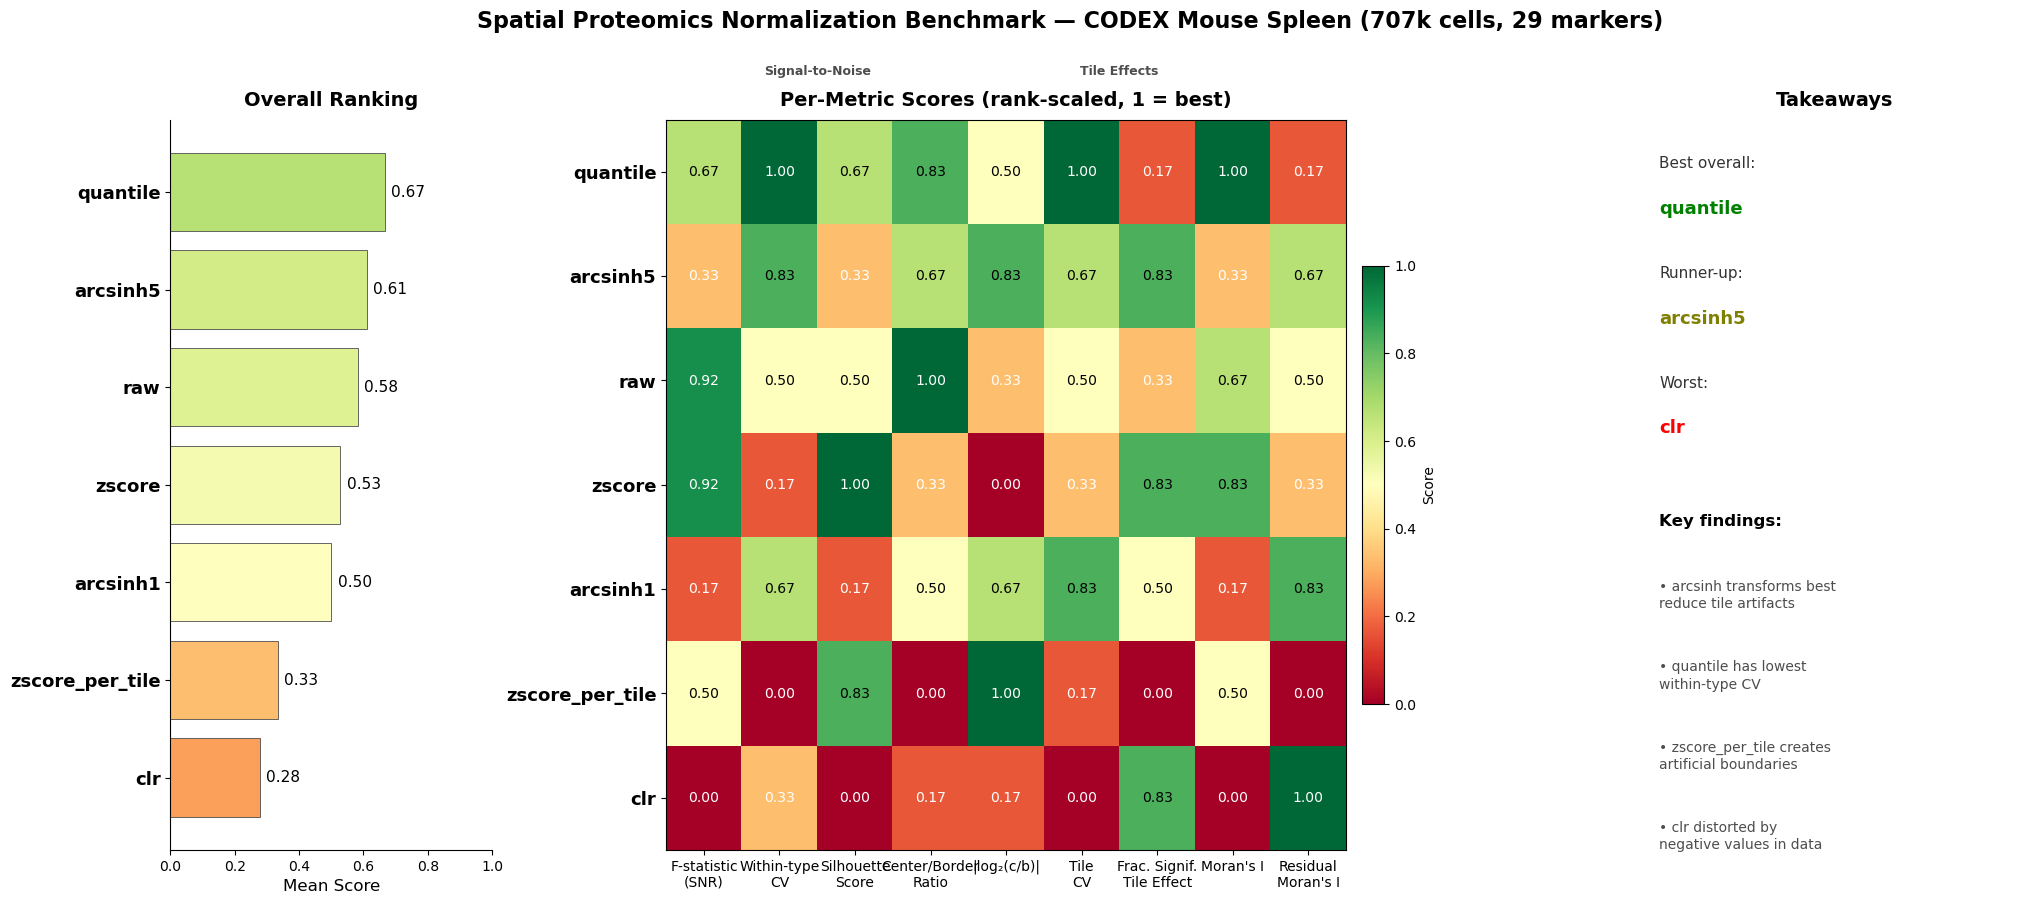

In [19]:
def plot_overview_slide(summary: pd.DataFrame, scaled: pd.DataFrame) -> plt.Figure:
    """Presentation-ready overview slide of the benchmark results."""

    method_order = scaled.mean(axis=1).sort_values(ascending=False).index.tolist()
    scaled_sorted = scaled.loc[method_order]
    summary_sorted = summary.loc[method_order]

    fig = plt.figure(figsize=(20, 10), facecolor="white")
    gs = fig.add_gridspec(
        1, 3, width_ratios=[1.1, 2.8, 1.2], wspace=0.35,
        left=0.05, right=0.97, top=0.85, bottom=0.12,
    )

    # --- Left panel: overall rank ---
    ax_rank = fig.add_subplot(gs[0])
    mean_scores = scaled_sorted.mean(axis=1)
    colors = plt.cm.RdYlGn(mean_scores.values)
    bars = ax_rank.barh(range(len(mean_scores)), mean_scores.values, color=colors, edgecolor="0.3", linewidth=0.6)
    ax_rank.set_yticks(range(len(mean_scores)))
    ax_rank.set_yticklabels(mean_scores.index, fontsize=13, fontweight="bold")
    ax_rank.set_xlabel("Mean Score", fontsize=12)
    ax_rank.set_title("Overall Ranking", fontsize=14, fontweight="bold", pad=10)
    ax_rank.set_xlim(0, 1)
    ax_rank.invert_yaxis()
    for i, v in enumerate(mean_scores.values):
        ax_rank.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=11)
    ax_rank.spines[["top", "right"]].set_visible(False)

    # --- Center panel: heatmap ---
    ax_heat = fig.add_subplot(gs[1])
    col_labels = {
        "median_f_statistic": "F-statistic\n(SNR)",
        "mean_within_cv": "Within-type\nCV",
        "mean_dynamic_range": "Dynamic\nRange",
        "silhouette_score": "Silhouette\nScore",
        "median_center_border_ratio": "Center/Border\nRatio",
        "median_|log₂(c/b)|": "|log₂(c/b)|",
        "mean_tile_cv": "Tile\nCV",
        "frac_signif_tile_effect": "Frac. Signif.\nTile Effect",
        "mean_morans_I": "Moran's I",
        "mean_residual_morans_I": "Residual\nMoran's I",
    }
    display_cols = [col_labels.get(c, c) for c in scaled_sorted.columns]

    im = ax_heat.imshow(scaled_sorted.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax_heat.set_xticks(range(len(display_cols)))
    ax_heat.set_xticklabels(display_cols, fontsize=10, ha="center")
    ax_heat.set_yticks(range(len(method_order)))
    ax_heat.set_yticklabels(method_order, fontsize=13, fontweight="bold")
    ax_heat.set_title("Per-Metric Scores (rank-scaled, 1 = best)", fontsize=14, fontweight="bold", pad=10)

    for i in range(scaled_sorted.shape[0]):
        for j in range(scaled_sorted.shape[1]):
            val = scaled_sorted.values[i, j]
            txt_color = "white" if val < 0.35 or val > 0.85 else "black"
            ax_heat.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=txt_color)

    # Category brackets
    cat_spans = [
        (0, 3, "Signal-to-Noise"),
        (4, 7, "Tile Effects"),
        (8, 9, "Spatial Autocorr."),
    ]
    for start, end, label in cat_spans:
        if end < scaled_sorted.shape[1]:
            mid = (start + end) / 2
            ax_heat.text(mid, -0.9, label, ha="center", va="bottom", fontsize=9,
                        fontweight="bold", color="0.3")

    cb = fig.colorbar(im, ax=ax_heat, shrink=0.6, pad=0.02)
    cb.set_label("Score", fontsize=10)

    # --- Right panel: key takeaways ---
    ax_text = fig.add_subplot(gs[2])
    ax_text.axis("off")

    takeaways = [
        ("Best overall:", f"{method_order[0]}", "green"),
        ("Runner-up:", f"{method_order[1]}", "olive"),
        ("Worst:", f"{method_order[-1]}", "red"),
        ("", "", ""),
        ("Key findings:", "", "black"),
        ("• arcsinh transforms best", "reduce tile artifacts", "0.3"),
        ("• quantile has lowest", "within-type CV", "0.3"),
        ("• zscore_per_tile creates", "artificial boundaries", "0.3"),
        ("• clr distorted by", "negative values in data", "0.3"),
    ]

    y = 0.95
    for line1, line2, color in takeaways:
        if not line1 and not line2:
            y -= 0.04
            continue
        if line2 and color in ("green", "olive", "red"):
            ax_text.text(0, y, line1, fontsize=11, color="0.2", transform=ax_text.transAxes, va="top")
            ax_text.text(0, y - 0.06, line2, fontsize=13, fontweight="bold", color=color,
                        transform=ax_text.transAxes, va="top")
            y -= 0.15
        elif line1.startswith("Key"):
            ax_text.text(0, y, line1, fontsize=12, fontweight="bold", color=color,
                        transform=ax_text.transAxes, va="top")
            y -= 0.09
        else:
            ax_text.text(0, y, f"{line1}\n{line2}", fontsize=10, color=color,
                        transform=ax_text.transAxes, va="top", linespacing=1.3)
            y -= 0.11

    ax_text.set_title("Takeaways", fontsize=14, fontweight="bold", pad=10)

    fig.suptitle(
        "Spatial Proteomics Normalization Benchmark — CODEX Mouse Spleen (707k cells, 29 markers)",
        fontsize=16, fontweight="bold", y=0.96,
    )

    return fig


fig_slide = plot_overview_slide(summary, scaled)
fig_slide.savefig("benchmark_overview_slide.png", dpi=200, facecolor="white", bbox_inches="tight")
fig_slide.savefig("benchmark_overview_slide.pdf", facecolor="white", bbox_inches="tight")

KeyboardInterrupt: 

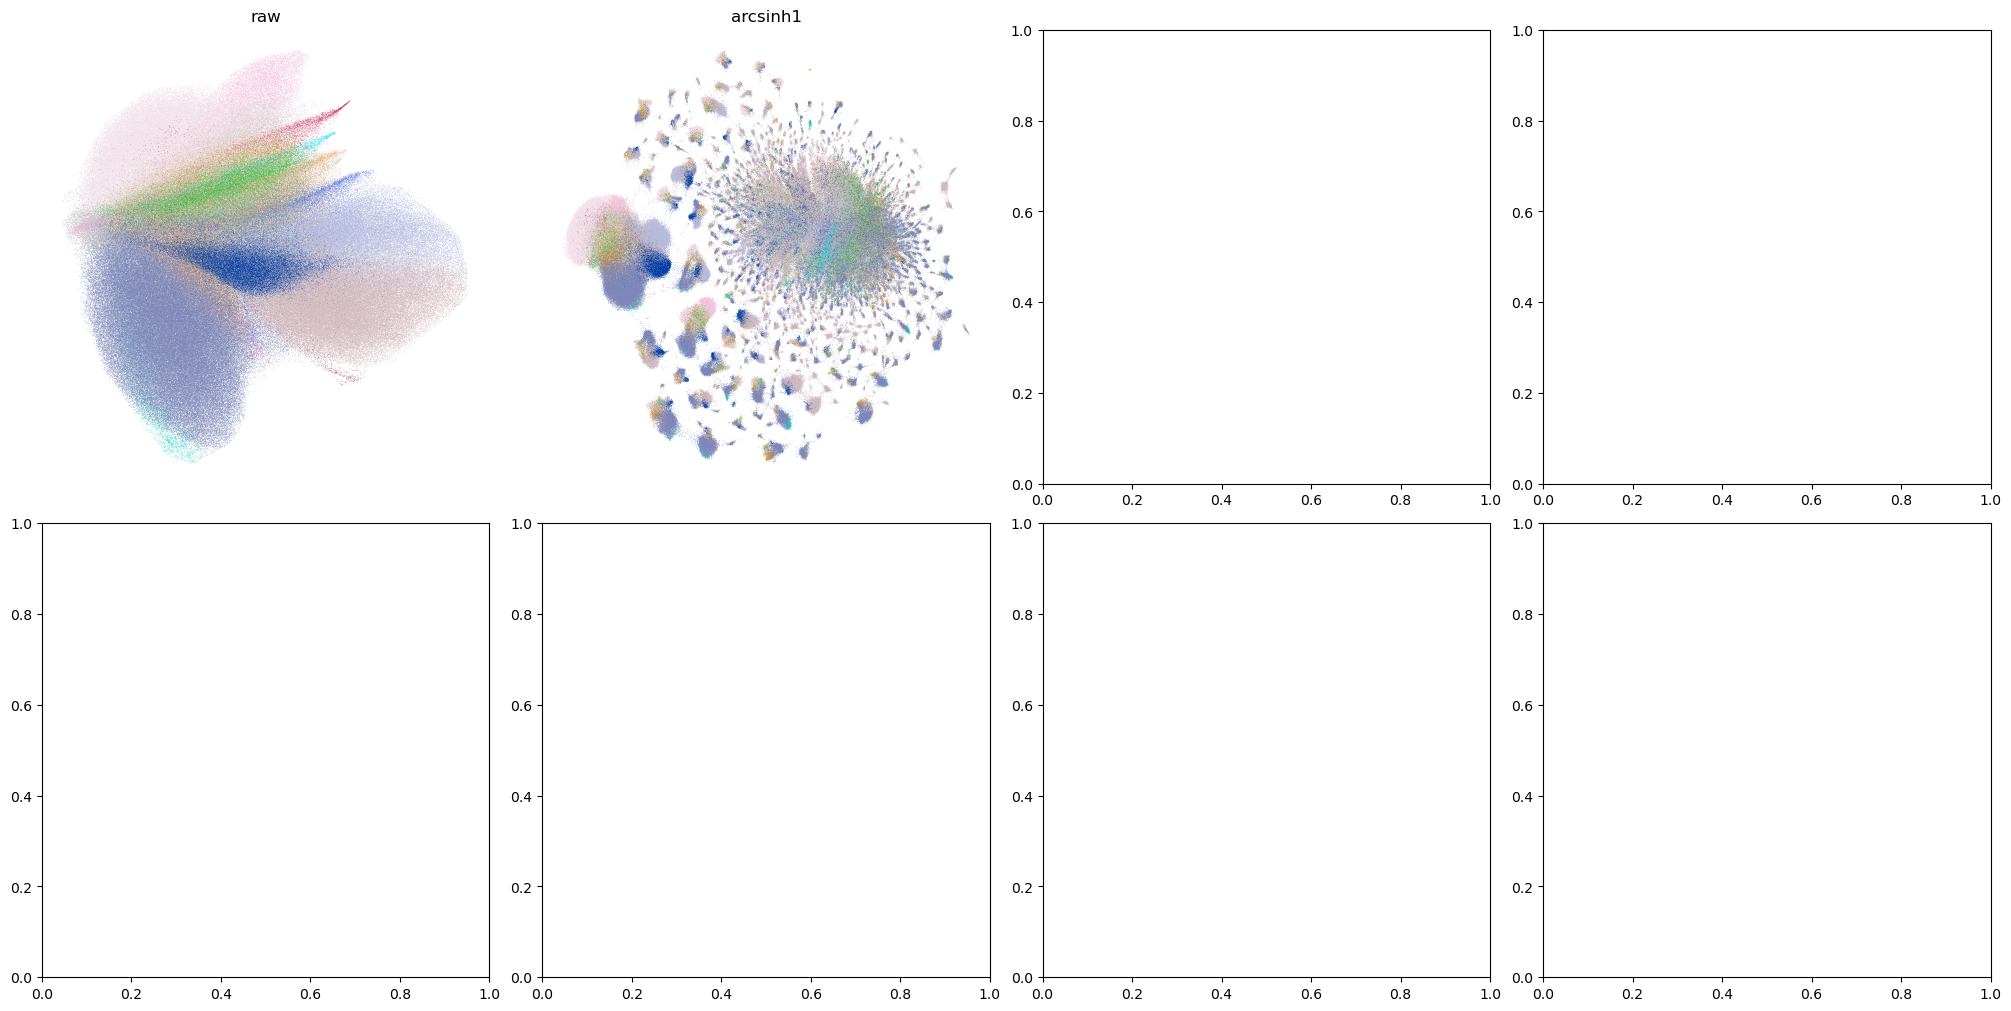

In [16]:
n_methods = len(adatas)
ncols = min(4, n_methods)
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 5 * nrows),
    squeeze=False, constrained_layout=True,
)

for idx, (name, ad) in enumerate(adatas.items()):
    ax = axes[idx // ncols, idx % ncols]
    tmp = ad.copy()

    X = tmp.X
    if sparse.issparse(X):
        X = np.asarray(X.todense())
    tmp.X = np.asarray(X, dtype=np.float64)

    n_comps = min(20, tmp.n_vars - 1, tmp.n_obs - 1)
    sc.pp.pca(tmp, n_comps=n_comps)
    sc.pp.neighbors(tmp, n_pcs=n_comps)
    sc.tl.umap(tmp)

    sc.pl.umap(tmp, color="cell_type", ax=ax, show=False, title=name,
               legend_loc="none", frameon=False, size=0.5)

for idx in range(len(adatas), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           fontsize=9, frameon=False, title="Cell type", title_fontsize=10,
           markerscale=3)

fig.suptitle("UMAP per Normalization Method", fontsize=15, fontweight="bold")
fig.savefig("umap_per_normalization.pdf", bbox_inches="tight")
fig.savefig("umap_per_normalization.png", dpi=150, bbox_inches="tight")